In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

import warnings
warnings.filterwarnings("ignore")


ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
def fire_season(month):
    return (month >= 5) & (month <= 10)    
    
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

ERA5 = ERA5.reindex(latitude=list(reversed(ERA5.latitude)))
ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

ERA5_anom = ERA5 - ERA5.mean('time')
d4pdf_anom = d4pdf - d4pdf.mean('time')
cam5_anom = cam5 - cam5.mean('time')


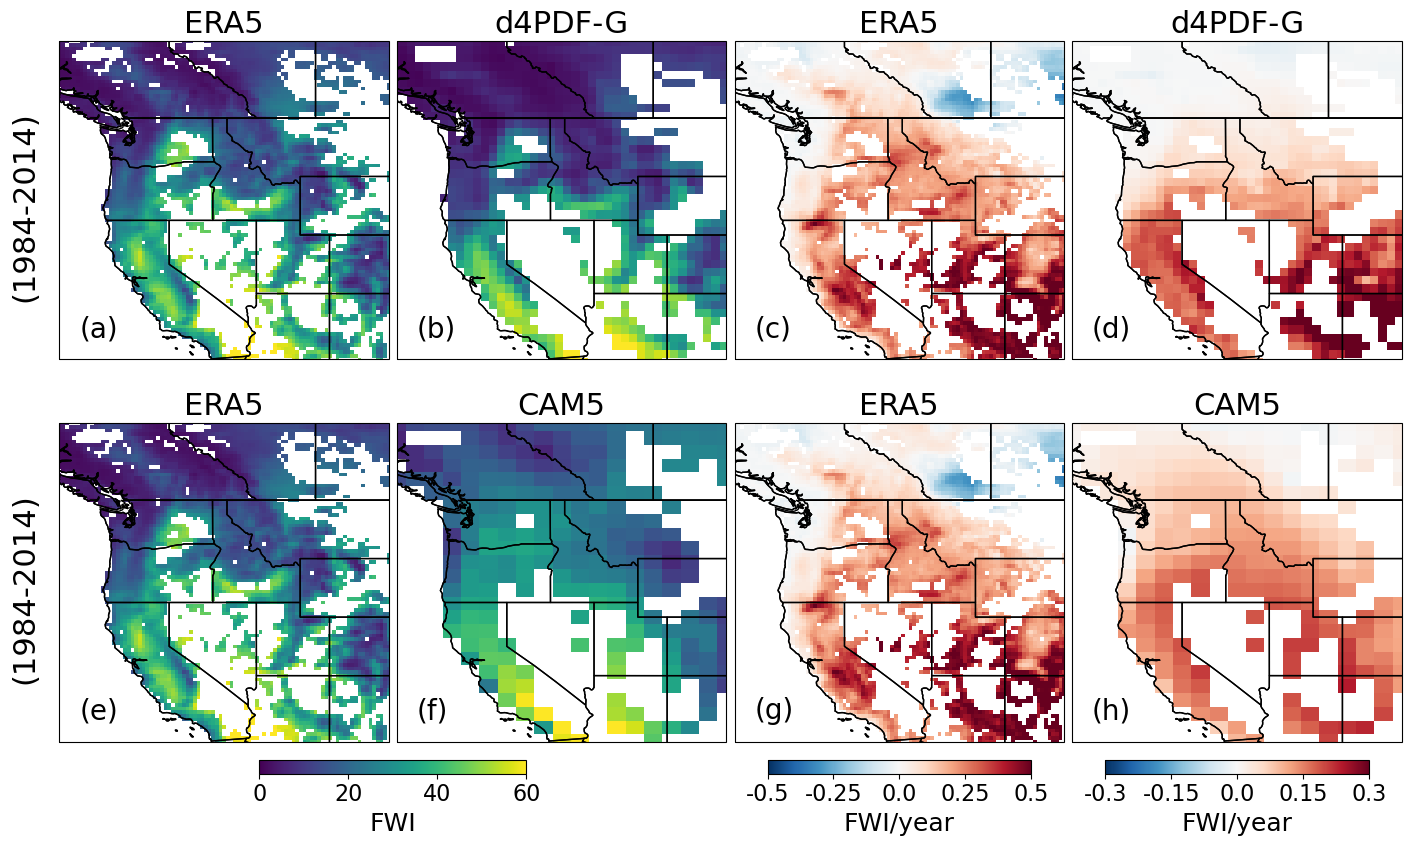

In [9]:

box = [(32,55),(232,256)]

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

labels = ['a','b','c','d','e','f','g','h']
count = 0
fig,axs = plt.subplots(2,4,figsize=(14,8.3), layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

for i,model in enumerate(['d4pdf','cam5']):
    
    if model == 'd4pdf':
        model_da = d4pdf
        (start,end) = ('1984','2014')
    elif model == 'cam5':
        model_da = cam5
        (start,end) = ('1984','2014')
        
    for j,da in enumerate([ERA5,model_da]):

        da_subset = da.sel(time=slice(start,end))
        da_subset = da_subset.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        # mean
        mean_im = da_subset.mean('time').plot(ax=axs[i][j],vmin=0,vmax=60,transform=ccrs.PlateCarree(),add_colorbar=False)

        # trend
        if j == 0:
            era_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][j+2],vmin=-0.5,vmax=0.5,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
        elif j == 1:
            model_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][j+2],vmin=-0.3,vmax=0.3,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

        for k in [0,2]:
            axs[i][j+k].coastlines()
            axs[i][j+k].add_feature(cf.BORDERS)
            axs[i][j+k].add_feature(cf.STATES)
            axs[i][j+k].set_extent([232.5,255, 32.5,54.18])#, crs=noproj)
            axs[i][int(2*j+(k-0.5*k))].text(0.06,0.07,'('+labels[count]+')',transform=axs[i][int(2*j+(k-0.5*k))].transAxes,fontdict=font)
            count += 1

font['size']=16
cb = fig.colorbar(mean_im, ax=axs[1, 0:2], shrink=0.4,orientation='horizontal')
cb.set_ticks([20*i for i in range(4)],labels=[str(20*i) for i in range(4)],fontdict=font)
font['size']=18
cb.set_label('FWI',fontdict=font)

font['size']=16
cb = fig.colorbar(era_trend_im, ax=axs[1, 2], shrink=0.8,orientation='horizontal')
cb.set_ticks([-0.5, -0.25, 0.0, 0.25, 0.5],labels=[str(val) for val in [-0.5, -0.25, 0.0, 0.25, 0.5]],fontdict=font)
font['size']=18
cb.set_label('FWI/year',fontdict=font)

font['size']=16
cb = fig.colorbar(model_trend_im, ax=axs[1, 3], shrink=0.8,orientation='horizontal')
cb.set_ticks([-0.3, -0.15, 0.0, 0.15, 0.3],labels=[str(val) for val in [-0.3, -0.15, 0.0, 0.15, 0.3]],fontdict=font)
font['size']=18
cb.set_label('FWI/year',fontdict=font)

font['size']=22
axs[0][0].text(-0.15,0.2,'(1984-2014)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.15,0.2,'(1984-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')


plot_titles = ['ERA5','d4PDF-G','ERA5','d4PDF-G','ERA5','CAM5','ERA5','CAM5']
for i,ax in enumerate(axs.flatten()):
    ax.set_title(plot_titles[i],fontdict=font)
    

plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig10_b.png',dpi=300)
